Device: cpu
Loading CIFAR-10 dataset...


100%|██████████| 170M/170M [38:07<00:00, 74.5kB/s]


Training images: 10000

Generator:
Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)

Discriminator:
Discriminator(
  (model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, i

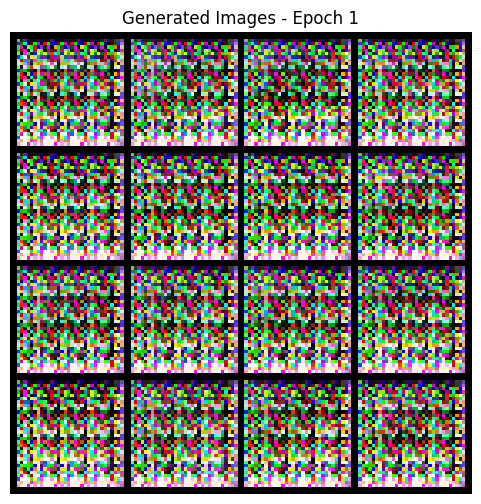

Epoch [2/3] Batch [0/157] D Loss: 0.0679 G Loss: 6.1719
Epoch [2/3] Batch [50/157] D Loss: 0.5820 G Loss: 2.7609
Epoch [2/3] Batch [100/157] D Loss: 0.6376 G Loss: 2.3745
Epoch [2/3] Batch [150/157] D Loss: 1.0637 G Loss: 3.8757


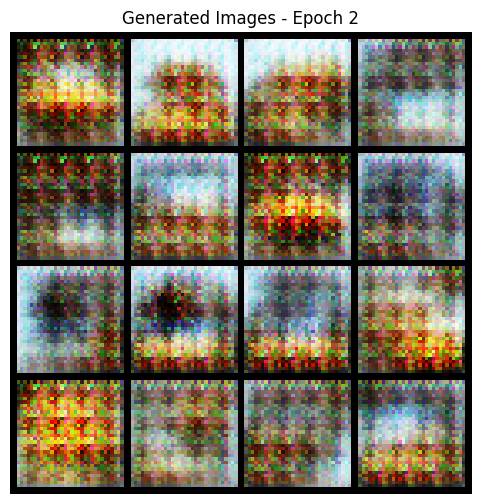

Epoch [3/3] Batch [0/157] D Loss: 0.7192 G Loss: 2.7188
Epoch [3/3] Batch [50/157] D Loss: 0.3068 G Loss: 3.5160
Epoch [3/3] Batch [100/157] D Loss: 1.0940 G Loss: 2.0559
Epoch [3/3] Batch [150/157] D Loss: 0.7291 G Loss: 2.1611


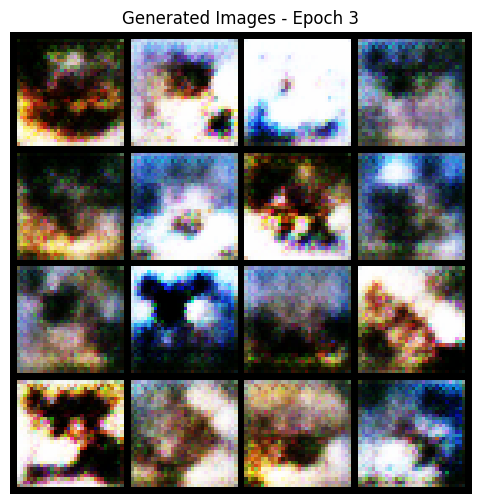


Training completed!


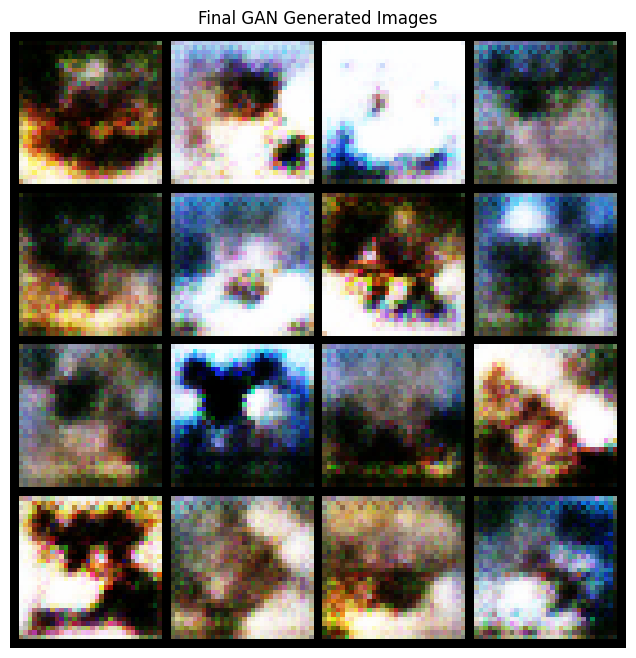

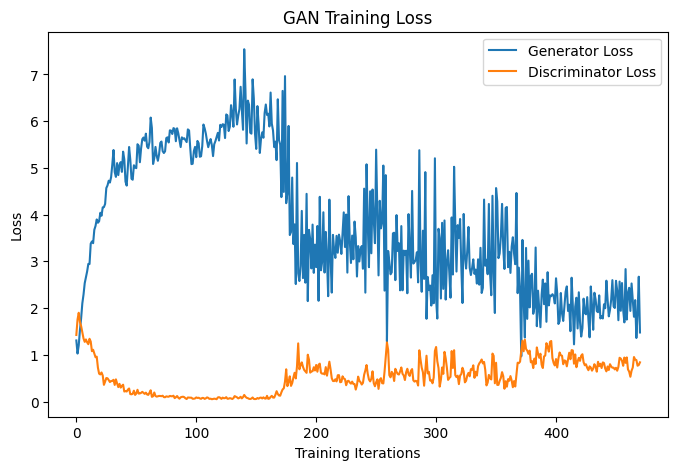


Generated images saved as: gan_generated_images.png

========== GAN EVALUATION ==========

The generated images are visually inspected for:

1. Image quality
2. Similarity to CIFAR-10 objects
3. Diversity between generated images
4. Presence of recognizable structures
5. Reduction of random noise as training progresses

Note:
This CPU-friendly experiment uses a reduced CIFAR-10 subset
and a small number of epochs. Therefore, image quality may
be lower than a fully trained GAN.

Experiment completed successfully!


In [1]:
# ============================================================
# EX 10: IMAGE GENERATION USING GENERATIVE ADVERSARIAL NETWORK
# DCGAN - CPU FRIENDLY VERSION
# Dataset: CIFAR-10
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

# ------------------------------------------------------------
# 1. Device
# ------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ------------------------------------------------------------
# 2. Parameters
# ------------------------------------------------------------
batch_size = 64
image_size = 32
channels = 3
latent_dim = 100
num_epochs = 3
lr = 0.0002

print("Loading CIFAR-10 dataset...")

# ------------------------------------------------------------
# 3. CIFAR-10 Dataset
# ------------------------------------------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Use a smaller subset for faster CPU training
dataset = torch.utils.data.Subset(dataset, range(10000))

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

print("Training images:", len(dataset))


# ============================================================
# 4. Generator
# ============================================================

class Generator(nn.Module):

    def __init__(self):
        super(Generator, self).__init__()

        self.model = nn.Sequential(

            # 100 x 1 x 1 -> 512 x 4 x 4
            nn.ConvTranspose2d(
                latent_dim, 512,
                kernel_size=4,
                stride=1,
                padding=0,
                bias=False
            ),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            # 512 x 4 x 4 -> 256 x 8 x 8
            nn.ConvTranspose2d(
                512, 256,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # 256 x 8 x 8 -> 128 x 16 x 16
            nn.ConvTranspose2d(
                256, 128,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # 128 x 16 x 16 -> 3 x 32 x 32
            nn.ConvTranspose2d(
                128, channels,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)


# ============================================================
# 5. Discriminator
# ============================================================

class Discriminator(nn.Module):

    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(

            # 3 x 32 x 32 -> 64 x 16 x 16
            nn.Conv2d(
                channels, 64,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 x 16 x 16 -> 128 x 8 x 8
            nn.Conv2d(
                64, 128,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # 128 x 8 x 8 -> 256 x 4 x 4
            nn.Conv2d(
                128, 256,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # 256 x 4 x 4 -> 1 x 1 x 1
            nn.Conv2d(
                256, 1,
                kernel_size=4,
                stride=1,
                padding=0,
                bias=False
            ),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).view(-1)


# ============================================================
# 6. Create Models
# ============================================================

G = Generator().to(device)
D = Discriminator().to(device)

print("\nGenerator:")
print(G)

print("\nDiscriminator:")
print(D)


# ============================================================
# 7. Loss and Optimizers
# ============================================================

criterion = nn.BCELoss()

optimizer_G = optim.Adam(
    G.parameters(),
    lr=lr,
    betas=(0.5, 0.999)
)

optimizer_D = optim.Adam(
    D.parameters(),
    lr=lr,
    betas=(0.5, 0.999)
)


# ============================================================
# 8. Training
# ============================================================

print("\nStarting GAN training...")
print("--------------------------------")

fixed_noise = torch.randn(16, latent_dim, 1, 1).to(device)

G_losses = []
D_losses = []

for epoch in range(num_epochs):

    for batch_idx, (real_images, _) in enumerate(dataloader):

        real_images = real_images.to(device)
        batch_size_current = real_images.size(0)

        # ----------------------------------------------------
        # Train Discriminator
        # ----------------------------------------------------

        optimizer_D.zero_grad()

        # Real images
        real_labels = torch.ones(
            batch_size_current,
            device=device
        )

        real_output = D(real_images)

        loss_real = criterion(
            real_output,
            real_labels
        )

        # Fake images
        noise = torch.randn(
            batch_size_current,
            latent_dim,
            1,
            1,
            device=device
        )

        fake_images = G(noise)

        fake_labels = torch.zeros(
            batch_size_current,
            device=device
        )

        fake_output = D(fake_images.detach())

        loss_fake = criterion(
            fake_output,
            fake_labels
        )

        # Total discriminator loss
        loss_D = loss_real + loss_fake

        loss_D.backward()
        optimizer_D.step()


        # ----------------------------------------------------
        # Train Generator
        # ----------------------------------------------------

        optimizer_G.zero_grad()

        noise = torch.randn(
            batch_size_current,
            latent_dim,
            1,
            1,
            device=device
        )

        fake_images = G(noise)

        output = D(fake_images)

        # Generator wants discriminator
        # to classify fake images as real
        loss_G = criterion(
            output,
            real_labels
        )

        loss_G.backward()
        optimizer_G.step()


        G_losses.append(loss_G.item())
        D_losses.append(loss_D.item())


        # Display progress
        if batch_idx % 50 == 0:

            print(
                f"Epoch [{epoch+1}/{num_epochs}] "
                f"Batch [{batch_idx}/{len(dataloader)}] "
                f"D Loss: {loss_D.item():.4f} "
                f"G Loss: {loss_G.item():.4f}"
            )


    # --------------------------------------------------------
    # Generate images after every epoch
    # --------------------------------------------------------

    with torch.no_grad():
        generated = G(fixed_noise).cpu()

    grid = torchvision.utils.make_grid(
        generated,
        nrow=4,
        normalize=True
    )

    plt.figure(figsize=(6, 6))
    plt.imshow(
        np.transpose(grid.numpy(), (1, 2, 0))
    )
    plt.title(f"Generated Images - Epoch {epoch+1}")
    plt.axis("off")
    plt.show()


# ============================================================
# 9. Final Generated Images
# ============================================================

print("\nTraining completed!")

G.eval()

with torch.no_grad():
    final_images = G(fixed_noise).cpu()

grid = torchvision.utils.make_grid(
    final_images,
    nrow=4,
    normalize=True
)

plt.figure(figsize=(8, 8))

plt.imshow(
    np.transpose(grid.numpy(), (1, 2, 0))
)

plt.title("Final GAN Generated Images")
plt.axis("off")
plt.show()


# ============================================================
# 10. Plot Generator and Discriminator Loss
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")

plt.xlabel("Training Iterations")
plt.ylabel("Loss")
plt.title("GAN Training Loss")

plt.legend()
plt.show()


# ============================================================
# 11. Save Generated Images
# ============================================================

torchvision.utils.save_image(
    final_images,
    "gan_generated_images.png",
    nrow=4,
    normalize=True
)

print("\nGenerated images saved as: gan_generated_images.png")


# ============================================================
# 12. Simple Visual Evaluation
# ============================================================

print("\n========== GAN EVALUATION ==========")

print("""
The generated images are visually inspected for:

1. Image quality
2. Similarity to CIFAR-10 objects
3. Diversity between generated images
4. Presence of recognizable structures
5. Reduction of random noise as training progresses

Note:
This CPU-friendly experiment uses a reduced CIFAR-10 subset
and a small number of epochs. Therefore, image quality may
be lower than a fully trained GAN.
""")

print("Experiment completed successfully!")